# SDSS-V DR19 SNC 100 pc Data

First, we need to select the SNC 100 pc data from SDSS-V DR19. This can be done using the `mwmAllStar-0.6.0.fits` file and looking at the `sdss5_target_flags`.

In [1]:
from astropy.table import Table, vstack

dr19 = vstack([Table.read('../../../DR19/mwmAllStar-0.6.0.fits', hdu=1),
               Table.read('../../../DR19/mwmAllStar-0.6.0.fits', hdu=2)])

In [2]:
from sdss_semaphore.targeting import TargetingFlags

flags = TargetingFlags(dr19["sdss5_target_flags"])



In [3]:
import numpy as np

snc = flags.in_carton_name("mwm_snc_100pc")


Select all of the stars in the `mwm_snc_100pc` cartons.

In [4]:
from astropy.table import unique

snc_100pc = unique(dr19[snc & (dr19['plx'] > 0)], keys='gaia_dr3_source_id', keep='first')

snc_100pc[['gaia_dr3_source_id', 'ra', 'dec']].write('../../SNC_DR19_ids.csv', format='csv', overwrite=True)

Select all of the white dwarfs within 100 pc.

In [5]:
MG = dr19['g_mag'] + 5 * np.log10(1e-3 * dr19['plx']) + 5
G_RP = dr19['g_mag'] - dr19['rp_mag']

snc_wd = unique(dr19[(dr19['plx'] - dr19['e_plx'] > 10) & (MG > 10 * G_RP + 5)], keys='gaia_dr3_source_id', keep='first')

snc_wd[['gaia_dr3_source_id', 'ra', 'dec']].write('../../WD_100pc_DR19_ids.csv', format='csv', overwrite=True)

/var/folders/17/d8lt9wb91k9bsvm5vm9g6q3w0000gn/T/ipykernel_60298/4020461742.py:1: RuntimeWarning: invalid value encountered in log10
  MG = dr19['g_mag'] + 5 * np.log10(1e-3 * dr19['plx']) + 5


The Gaia information for the above sources is pulled from the [Gaia archive](https://gea.esac.esa.int/archive/) by uploading these as a user table and running a query like:
```
SELECT g.source_id, g.ra, g.ra_error, g.dec, g.dec_error, g.parallax, g.parallax_error,
        g.g_rp,  g.phot_g_mean_mag, g.phot_g_mean_flux_over_error
FROM gaiadr3.gaia_source as g
JOIN user_imedan.snc_dr19 ON user_imedan.snc_dr19.gaia_dr3_source_id = g.source_id
```

# SDSS-V SNC Sky Plots

Below I will create a few sky plots showing the distriubtion of SNC 100 pc objects.

First, let us look at the distriubtion of stars with either a BOSS or APOGEE spectrum in DR19.

In [6]:
import healpy as hp
import os
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pylab as plt
from snc_sf.utils import coord2healpix
%matplotlib inline
plt.style.use('%s/mystyle.mplstyle' % os.environ['MPL_STYLES'])


In [7]:
dr19 = vstack([Table.read('../../../DR19/mwmAllStar-0.6.0.fits', hdu=1)])
flags = TargetingFlags(dr19["sdss5_target_flags"])
snc = flags.in_carton_name("mwm_snc_100pc")


boss_coord = SkyCoord(ra=dr19[snc & (dr19['plx'] > 0) & (dr19['n_boss_visits'] > 0)]['ra'] * u.deg,
                      dec=dr19[snc & (dr19['plx'] > 0) & (dr19['n_boss_visits'] > 0)]['dec'] * u.deg,
                      frame='icrs')

dr19 = vstack([Table.read('../../../DR19/mwmAllStar-0.6.0.fits', hdu=2)])
flags = TargetingFlags(dr19["sdss5_target_flags"])
snc = flags.in_carton_name("mwm_snc_100pc")

apogee_coord = SkyCoord(ra=dr19[snc & (dr19['plx'] > 0) & (dr19['n_apogee_visits'] > 0)]['ra'] * u.deg,
                        dec=dr19[snc & (dr19['plx'] > 0) & (dr19['n_apogee_visits'] > 0)]['dec'] * u.deg,
                        frame='icrs')


In [8]:
hpboss = hp.pixelfunc.ang2pix(2 ** 4, boss_coord.galactic.l.deg, boss_coord.galactic.b.deg, lonlat=True)

ipix, counts = np.unique(hpboss, return_counts=True)
hpboss = np.zeros(hp.nside2npix(2 ** 4))
hpboss[ipix] = counts
hpboss[hpboss == 0] = np.nan

np.float64(49.926000000000386)

<Figure size 1500x700 with 0 Axes>

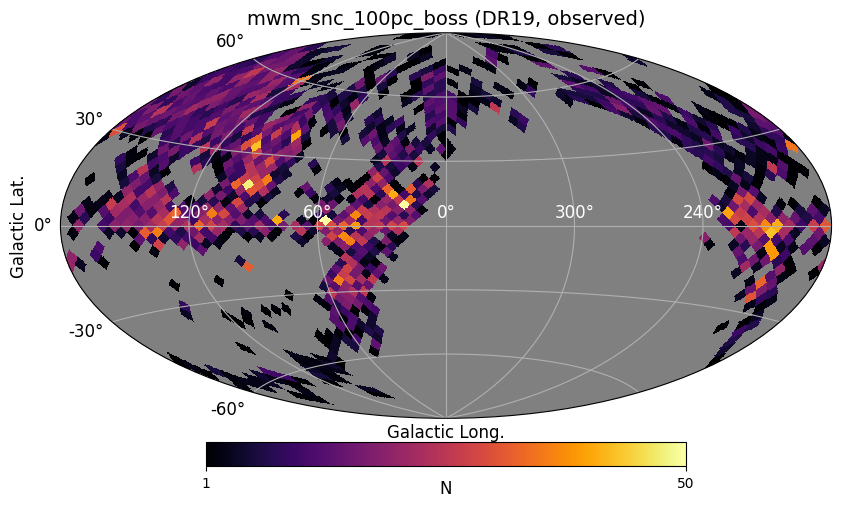

In [9]:
from healpy.newvisufunc import projview, newprojplot
from healpy.visufunc import graticule

f = plt.figure(figsize=(15, 7))
projview(
    hpboss,
    coord='G',
    graticule=True,
    graticule_labels=True,
    unit="N",
    xlabel="Galactic Long.",
    ylabel="Galactic Lat.",
    cb_orientation="horizontal",
    projection_type="aitoff",
    cmap='inferno',
    fig=f,
    title='mwm_snc_100pc_boss (DR19, observed)',
    xtick_label_color='w',
    max=50
)
plt.savefig('paper_plots/BOSS_sky_plot.png', bbox_inches='tight')

<Figure size 1500x700 with 0 Axes>

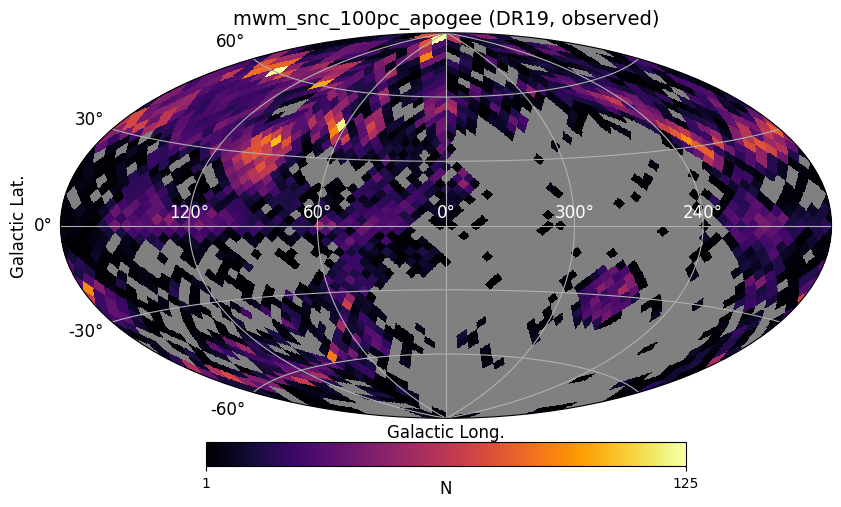

In [10]:
phi = apogee_coord.galactic.l.rad
theta = 0.5 * np.pi - apogee_coord.galactic.b.rad
hpboss = hp.pixelfunc.ang2pix(2 ** 4, apogee_coord.galactic.l.deg, apogee_coord.galactic.b.deg, lonlat=True)

ipix, counts = np.unique(hpboss, return_counts=True)
hpboss = np.zeros(hp.nside2npix(2 ** 4))
hpboss[ipix] = counts
hpboss[hpboss == 0] = np.nan

np.nanpercentile(hpboss, 99.9)

f = plt.figure(figsize=(15, 7))
ax = projview(
    hpboss,
    coord='G',
    graticule=True,
    graticule_labels=True,
    unit="N",
    xlabel="Galactic Long.",
    ylabel="Galactic Lat.",
    cb_orientation="horizontal",
    projection_type="aitoff",
    cmap='inferno',
    fig=f,
    title='mwm_snc_100pc_apogee (DR19, observed)',
    xtick_label_color='w',
    max=125
)

plt.savefig('paper_plots/APOGEE_sky_plot.png', bbox_inches='tight')

Now we will look at sky plots of the overall SNC 100 pc carton (stars that we submited for targeting) and objects that were selected to recieve a spectrum by the end of the survey by the survey planning tool, [robostrategy](https://github.com/sdss/robostrategy/). These use the internal robostrategy files.

In [11]:
boss_carton = Table.read('../../../DR19/rsCompletenessFinal-mwm_snc_100pc_boss-zeta-3-both.fits', hdu=1)

apogee_carton = Table.read('../../../DR19/rsCompletenessFinal-mwm_snc_100pc_apogee-zeta-3-both.fits', hdu=1)

In [12]:
boss_coord = SkyCoord(ra=boss_carton['ra'] * u.deg,
                      dec=boss_carton['dec'] * u.deg,
                      frame='icrs')

apogee_coord = SkyCoord(ra=apogee_carton['ra'] * u.deg,
                      dec=apogee_carton['dec'] * u.deg,
                      frame='icrs')



<Figure size 1500x700 with 0 Axes>

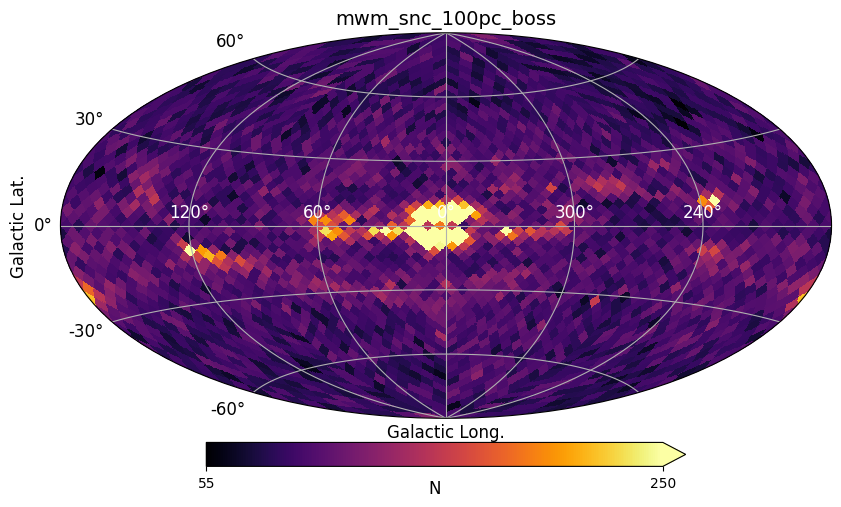

In [13]:
hpboss = hp.pixelfunc.ang2pix(2 ** 4, boss_coord.galactic.l.deg, boss_coord.galactic.b.deg, lonlat=True)

ipix, counts = np.unique(hpboss, return_counts=True)
hpboss = np.zeros(hp.nside2npix(2 ** 4))
hpboss[ipix] = counts
hpboss[hpboss == 0] = np.nan

np.nanpercentile(hpboss, 99.9)


f = plt.figure(figsize=(15, 7))
projview(
    hpboss,
    coord='G',
    graticule=True,
    graticule_labels=True,
    unit="N",
    xlabel="Galactic Long.",
    ylabel="Galactic Lat.",
    cb_orientation="horizontal",
    projection_type="aitoff",
    cmap='inferno',
    fig=f,
    title='mwm_snc_100pc_boss',
    xtick_label_color='w',
    max=250
)
plt.savefig('paper_plots/BOSS_carton_sky_plot.png', bbox_inches='tight')


<Figure size 1500x700 with 0 Axes>

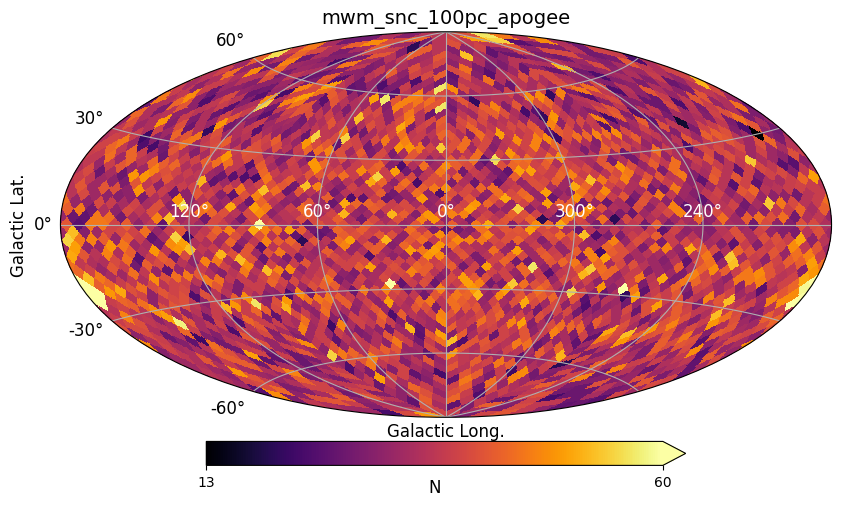

In [14]:
phi = apogee_coord.galactic.l.rad
theta = 0.5 * np.pi - apogee_coord.galactic.b.rad
hpboss = hp.pixelfunc.ang2pix(2 ** 4, apogee_coord.galactic.l.deg, apogee_coord.galactic.b.deg, lonlat=True)

ipix, counts = np.unique(hpboss, return_counts=True)
hpboss = np.zeros(hp.nside2npix(2 ** 4))
hpboss[ipix] = counts
hpboss[hpboss == 0] = np.nan

np.nanpercentile(hpboss, 99.9)

f = plt.figure(figsize=(15, 7))
ax = projview(
    hpboss,
    coord='G',
    graticule=True,
    graticule_labels=True,
    unit="N",
    xlabel="Galactic Long.",
    ylabel="Galactic Lat.",
    cb_orientation="horizontal",
    projection_type="aitoff",
    cmap='inferno',
    fig=f,
    title='mwm_snc_100pc_apogee',
    xtick_label_color='w',
    max=60
)

plt.savefig('paper_plots/APOGEE_carton_sky_plot.png', bbox_inches='tight')

In [15]:
boss_coord = SkyCoord(ra=boss_carton[boss_carton['satisfied'] > 0]['ra'] * u.deg,
                      dec=boss_carton[boss_carton['satisfied'] > 0]['dec'] * u.deg,
                      frame='icrs')

apogee_coord = SkyCoord(ra=apogee_carton[apogee_carton['satisfied'] > 0]['ra'] * u.deg,
                      dec=apogee_carton[apogee_carton['satisfied'] > 0]['dec'] * u.deg,
                      frame='icrs')





<Figure size 1500x700 with 0 Axes>

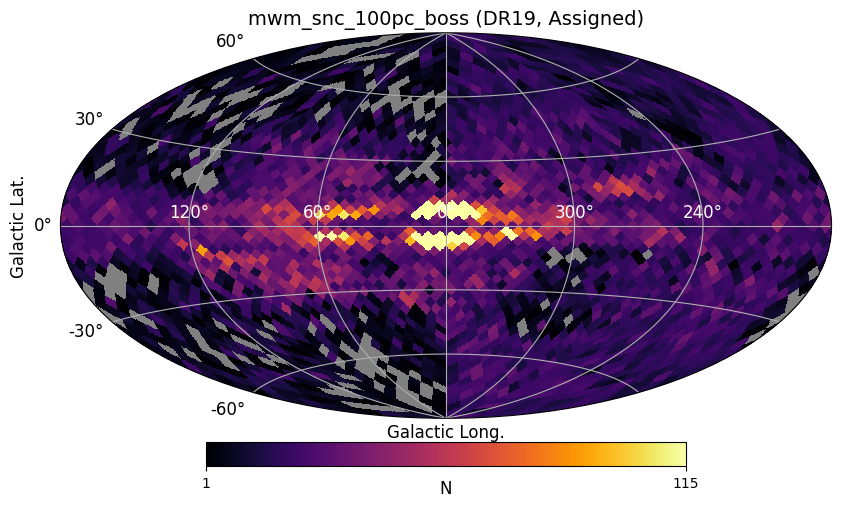

In [16]:
hpboss = hp.pixelfunc.ang2pix(2 ** 4, boss_coord.galactic.l.deg, boss_coord.galactic.b.deg, lonlat=True)

ipix, counts = np.unique(hpboss, return_counts=True)
hpboss = np.zeros(hp.nside2npix(2 ** 4))
hpboss[ipix] = counts
hpboss[hpboss == 0] = np.nan

np.nanpercentile(hpboss, 99.9)


f = plt.figure(figsize=(15, 7))
projview(
    hpboss,
    coord='G',
    graticule=True,
    graticule_labels=True,
    unit="N",
    xlabel="Galactic Long.",
    ylabel="Galactic Lat.",
    cb_orientation="horizontal",
    projection_type="aitoff",
    cmap='inferno',
    fig=f,
    title='mwm_snc_100pc_boss (DR19, Assigned)',
    xtick_label_color='w',
    max=115
)
plt.savefig('paper_plots/BOSS_assigned_sky_plot.png', bbox_inches='tight')




<Figure size 1500x700 with 0 Axes>

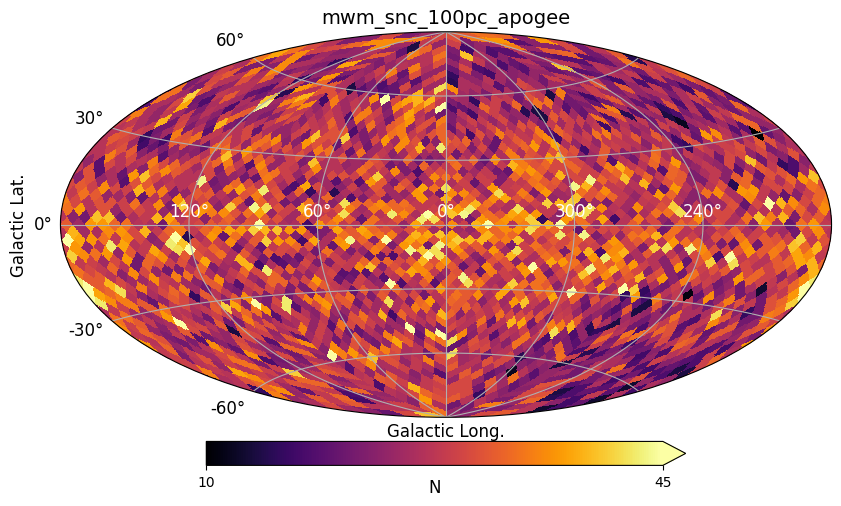

In [17]:
phi = apogee_coord.galactic.l.rad
theta = 0.5 * np.pi - apogee_coord.galactic.b.rad
hpboss = hp.pixelfunc.ang2pix(2 ** 4, apogee_coord.galactic.l.deg, apogee_coord.galactic.b.deg, lonlat=True)

ipix, counts = np.unique(hpboss, return_counts=True)
hpboss = np.zeros(hp.nside2npix(2 ** 4))
hpboss[ipix] = counts
hpboss[hpboss == 0] = np.nan

np.nanpercentile(hpboss, 99.9)

f = plt.figure(figsize=(15, 7))
ax = projview(
    hpboss,
    coord='G',
    graticule=True,
    graticule_labels=True,
    unit="N",
    xlabel="Galactic Long.",
    ylabel="Galactic Lat.",
    cb_orientation="horizontal",
    projection_type="aitoff",
    cmap='inferno',
    fig=f,
    title='mwm_snc_100pc_apogee',
    xtick_label_color='w',
    max=45
)

plt.savefig('paper_plots/APOGEE_assigned_sky_plot.png', bbox_inches='tight')
